# Assinatura Digital

As assinaturas digitais vão além da autenticação e integridade dos dados, garantindo também o **não repudio**. Uma assinatura digital permite que qualquer pessoa, não apenas o destinatário, possa responder a duas perguntas importantes:

1. Quem enviou a mensagem?
2. A mensagem foi modificada durante o envio?

Assim como as assinaturas manuscritas, as assinaturas digitais oferecem uma forma de validar a **autoria** e a **integridade** de uma mensagem.

Como funciona?
Assinaturas digitais são criadas tradicionalmente combinando uma função hash com a criptografia de chave pública. Para assinar digitalmente uma mensagem, o emissor segue estes passos:

1. **Hash da mensagem:** O emissor primeiro aplica uma função hash na mensagem, gerando um valor hash que representa o conteúdo da mensagem de forma compacta e única.

2. **Criptografia utilizando chave privada:** Em seguida, esse valor hash é criptografado com a chave privada do emissor, gerando a assinatura digital. Nesse processo:


3. **Envio da mensagem e assinatura:** A mensagem original e a assinatura digital são enviadas juntas ao destinatário.

A figura abaixo mostra um exemplo de como Bob implementaria o processo de enviar uma mensagem assinada.


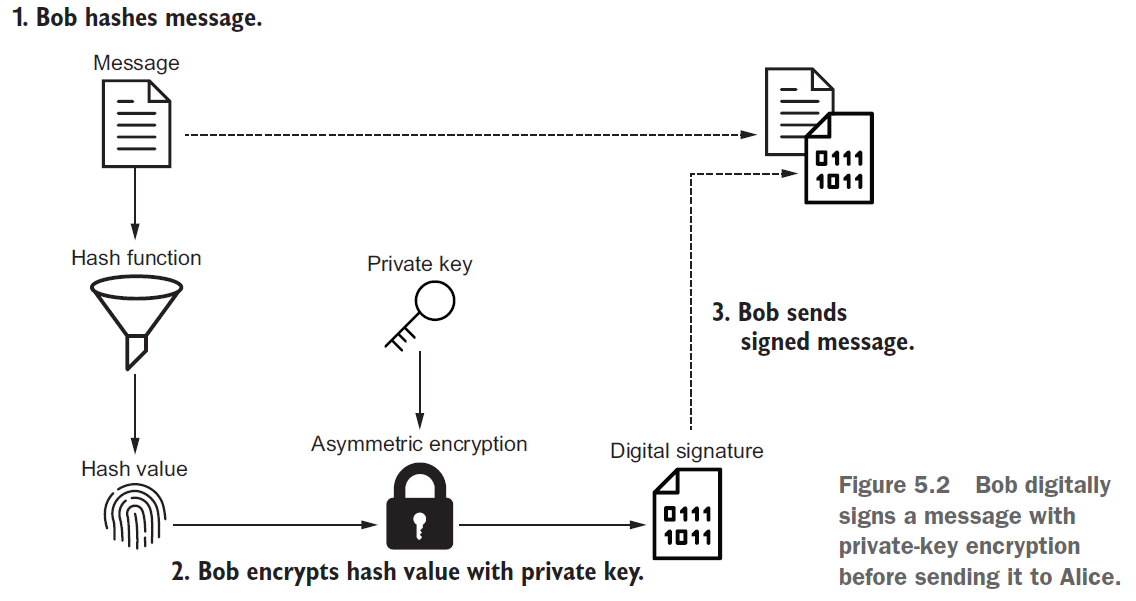

#### Assinatura Digital: A Diferença entre Confidencialidade e Não Repudiação
A assinatura digital é transmitida abertamente com a mensagem; ela **não é um segredo**. Isso pode parecer estranho para quem não estudou segurança da informação 🤓, já que a assinatura é tecnicamente um texto cifrado, e qualquer pessoa pode **descriptografá-la com a chave pública** do emissor.

Por que isso é permitido? Porque o objetivo da assinatura digital não é garantir **confidencialidade**, mas sim o **não repudio**. Se um atacante descriptografar a assinatura digital, tudo o que ele obterá é o valor hash da mensagem, o que não revela nenhuma informação confidencial.

O ponto central da assinatura digital é **impedir** que o emissor **negue** que ele enviou a mensagem (não repudio), e garantir que a mensagem não foi alterada durante o envio.

# Assinatura Digital em Python

## Assinatura Digital com **RSA**

Este exemplo demonstra como assinar uma mensagem utilizando o algoritmo **SHA-256**, a criptografia de chave pública RSA (utilizando a **chave privada!**), e um esquema de preenchimento conhecido como **PSS** (*Probabilistic Signature Scheme*). O método `RSAPrivateKey.sign` combina esses três elementos para gerar a assinatura digital.

* Os esquemas de preenchimento (padding) para assinatura digital com RSA e criptografia de chave pública RSA não são os mesmos. O preenchimento OAEP é recomendado para a criptografia RSA; o preenchimento PSS é recomendado para assinaturas digitais com RSA. Esses dois esquemas de preenchimento não são intercambiáveis.

#### Geração do par de chaves

In [ ]:
from cryptography.hazmat.backends import default_backend
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.primitives.asymmetric import rsa

private_key_bob = rsa.generate_private_key(
                                            public_exponent=65537,
                                            key_size=3072,
                                            backend=default_backend(),
                                          )

public_key_bob = private_key_bob.public_key()

#### Processo de assinatura



In [ ]:
import json
from cryptography.hazmat.primitives.asymmetric import padding
from cryptography.hazmat.primitives import hashes

# Mensagem que será assinada
message = b'Alice compre 100 acoes da PETR4. Ass. Bob'

# Configuração do esquema de preenchimento (padding)
# Usando PSS (Probabilistic Signature Scheme) com MGF1 e SHA-256
padding_config = padding.PSS(
                              mgf=padding.MGF1(hashes.SHA256()),
                              salt_length=padding.PSS.MAX_LENGTH
                            )

# Assinatura da mensagem usando a chave privada de Bob, com a configuração de padding e SHA-256
signature = private_key_bob.sign(
                              message,
                              padding_config,
                              hashes.SHA256() # A função hash utilizada para gerar o resumo da mensagem
                            )

# Criação de um dicionário com a mensagem e a assinatura
signed_msg = {
              'message': list(message),
              'signature': list(signature),
             }

# Convertida em formato JSON
msg_to_alice = json.dumps(signed_msg)

print(msg_to_alice)


{"message": [65, 108, 105, 99, 101, 32, 99, 111, 109, 112, 114, 101, 32, 49, 48, 48, 32, 97, 99, 111, 101, 115, 32, 100, 97, 32, 80, 69, 84, 82, 52, 46, 32, 65, 115, 115, 46, 32, 66, 111, 98], "signature": [54, 53, 38, 59, 202, 226, 32, 6, 151, 120, 80, 68, 197, 169, 216, 255, 49, 84, 206, 45, 255, 6, 249, 238, 83, 7, 0, 43, 231, 125, 21, 20, 128, 104, 76, 196, 48, 130, 200, 181, 229, 80, 185, 122, 131, 191, 244, 80, 181, 246, 139, 157, 32, 51, 243, 84, 140, 42, 97, 96, 46, 6, 63, 230, 71, 202, 18, 102, 212, 47, 24, 19, 9, 136, 29, 93, 116, 88, 253, 140, 46, 249, 151, 13, 241, 50, 247, 107, 69, 177, 176, 12, 182, 56, 112, 174, 6, 0, 31, 202, 3, 129, 55, 41, 10, 46, 53, 153, 120, 1, 130, 116, 243, 67, 78, 43, 178, 233, 52, 90, 185, 207, 190, 225, 251, 57, 153, 231, 162, 202, 89, 254, 46, 160, 78, 53, 206, 24, 233, 235, 241, 10, 189, 248, 170, 16, 53, 196, 42, 67, 20, 113, 114, 163, 169, 16, 211, 69, 213, 32, 110, 224, 34, 102, 162, 92, 42, 151, 215, 100, 167, 162, 70, 163, 143, 4, 145, 

In [ ]:
print("Assinatura (hex):", signature.hex())
print("Tamanho:", len(signature), "bytes" )
print("Tamanho:", len(signature)*8, "bits (!)" )

Assinatura (hex): 55ae623a9396f5f75536d8786cc15396061fcf109c7f2fc2134d542dddcc3d6af48fe2b93421ae479e18ba08b6c8ed29ac04b05dcf3667cc46a72f4ebb4cc9904a6b720df47ba893aadc4544e1dc26da899f873b4b0aae2931b7117f6b4667d74e6cf2f550e3db4ba0896a8e4b0f30a0356a64eb2cd6b8e9ce628e4b9902a3a4da0aaacdeda924a8cd92307f4239200c547e210af3cb2e8af9b9d4f4c0e19535d5509001c08efc018aa456a91e3b227ec7e79bff44d0fd7728780e4a7013bf04cc2bc83c0a1c77e2dab1c1eec329c89d6a226a795338558c42c9e77bcf5689c0e8f7849a8394fb58cbc0cfe05b3260dbb1fec6502f6e1f23442d15da4a30db1c992373d786c202b7a990214516104647e2e09cebdea4f14a97186ed6034517e822f6fac081377eed0ab9d80fc520064a139511c669b04c2bd913879a8e572138029ad16406d709576d3071631d61a1e4252775f55518db1700c306b1fe738380e3912209b3bf9aeb8e8161ff58b2249092bee57ace885df66933496a8ab5857f
Tamanho: 384 bytes
Tamanho: 3072 bits (!)


#### Verificação de Assinatura Digital

Após Alice receber a mensagem e a assinatura digital de Bob, ela segue três etapas para verificar a autenticidade:

1. **Gera o hash da mensagem:** Alice aplica a mesma função hash utilizada por Bob para criar um valor hash da mensagem.
2. **Descriptografa a assinatura:** Ela usa a chave pública de Bob para sescriptografar a assinatura digital.
3. **Compara os valores de hash:** Alice compara o hash que ela gerou com o valor obtido após a descriptografia.

Se os valores de hash coincidirem, Alice pode confiar que a mensagem não foi alterada e realmente foi enviada por Bob.

A Figura abaixo mostra como Alice, a receptora, implementa este processo de verificação.

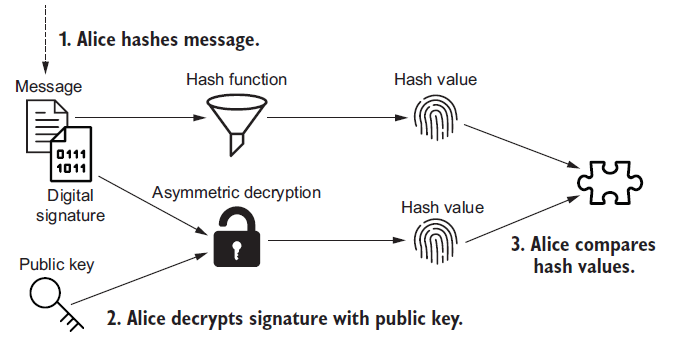

Todas as três etapas da verificação de uma assinatura digital são executadas automaticamente pelo método `RSAPublicKey.verify`.
- Se o valor de hash gerado por Alice não coincidir com o valor de hash descriptografado da assinatura de Bob, o método lançará uma **exceção InvalidSignature**.
- Caso os valores coincidam, Alice pode confirmar que a mensagem não foi alterada e que foi enviada por alguém com a chave privada de Bob — presumivelmente, o próprio Bob.

In [ ]:
import json
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.asymmetric import padding
from cryptography.exceptions import InvalidSignature

In [ ]:
# Alice recebe a mensagem de Bob.
msg_from_bob = msg_to_alice

# A mensagem assinada é carregada de uma string JSON, convertendo-a em um dicionário Python.
signed_msg = json.loads(msg_from_bob)

# A mensagem original e a assinatura são extraídas do dicionário e convertidas em bytes.
message = bytes(signed_msg['message'])
signature = bytes(signed_msg['signature'])

# Configuração do preenchimento PSS para verificação da assinatura digital.
padding_config = padding.PSS(
                              mgf=padding.MGF1(hashes.SHA256()),
                              salt_length=padding.PSS.MAX_LENGTH
                            )
# Validando a assinatura
try:
  # O método verify da chave pública é chamado para verificar a assinatura.
  public_key_bob.verify(
                        signature,      # A assinatura a ser verificada
                        message,        # A mensagem original que foi assinada
                        padding_config, # Configuração de preenchimento PSS
                        hashes.SHA256() # A mesma função hash usada para assinar a mensagem
                      )

  # Se a verificação for bem-sucedida, imprime que a assinatura é válida.
  print('Assinatura válida')
except InvalidSignature:
  # Se a verificação falhar, captura a exceção InvalidSignature e imprime que a assinatura é inválida.
  print('Assinatura inválida')



Assinatura válida


#### ***Padding PSS - Probabilistic Signature Scheme***

O PSS (*Probabilistic Signature Scheme*) é um esquema de preenchimento (padding) usado em assinaturas digitais com RSA. Ele é amplamente recomendado por oferecer maior segurança em comparação com outros esquemas de preenchimento, como o PKCS#1 v1.5. O PSS introduz um elemento de aleatoriedade (probabilístico), o que ajuda a proteger contra certos ataques criptográficos. Abaixo está uma explicação detalhada de como o PSS funciona e por que ele é considerado seguro:


**1. Objetivo do PSS**

O PSS tem o propósito de garantir que cada vez que uma mensagem for assinada digitalmente, mesmo que o conteúdo da mensagem seja idêntico, o resultado da assinatura será diferente. Isso é alcançado por meio da aleatoriedade no processo de preenchimento. Ele é projetado para aumentar a segurança da assinatura digital contra ataques de análise ou reprodução, como os ataques de texto cifrado escolhido.


**2. Componentes Principais do PSS**

O PSS consiste em três componentes principais:

Função de Geração de Máscara (MGF1): É uma função determinística que gera uma sequência de bytes de tamanho arbitrário a partir de um valor de entrada. No PSS, MGF1 é usada para gerar uma máscara que será aplicada ao valor de hash.
Salt: O salt é um valor aleatório gerado para cada assinatura. Esse valor adiciona entropia à assinatura, o que significa que mesmo que a mesma mensagem seja assinada repetidamente, as assinaturas geradas serão diferentes.
Função Hash: PSS usa uma função hash (como SHA-256) para gerar um valor hash fixo da mensagem. A função hash é fundamental para garantir a integridade da mensagem.


**3. Processo de Assinatura com PSS**

O processo de assinatura com PSS envolve várias etapas, descritas a seguir:

a) Hash da Mensagem
O emissor da assinatura (por exemplo, Bob) primeiro aplica uma função hash (como SHA-256) à mensagem que deseja assinar. Isso gera um valor hash fixo que compacta os dados da mensagem em um tamanho menor e representa sua integridade.

b) Geração de Salt
Um valor aleatório chamado salt é gerado. O salt adiciona aleatoriedade ao esquema de assinatura e garante que, mesmo que a mesma mensagem seja assinada novamente, a assinatura gerada será diferente.

c) Aplicação da Função de Geração de Máscara (MGF1)
O valor de hash e o salt são combinados com a função de geração de máscara (MGF1) para criar uma máscara que será aplicada ao hash. Essa máscara ajuda a proteger contra ataques e adiciona mais complexidade ao esquema de preenchimento.

d) Criação do Bloco de Assinatura
O valor de hash e o salt são então combinados com o bloco de preenchimento, formando o bloco de assinatura. Esse bloco de assinatura é o que será criptografado usando a chave privada do emissor.

e) Criptografia com a Chave Privada
O bloco de assinatura é criptografado usando a chave privada do emissor, gerando a assinatura digital final. Essa assinatura é então transmitida junto com a mensagem original.


**4. Processo de Verificação com PSS**

O processo de verificação do PSS também envolve várias etapas:

a) Hash da Mensagem
O receptor (por exemplo, Alice) primeiro calcula o hash da mensagem recebida, aplicando a mesma função hash utilizada pelo emissor.

b) Descriptografia da Assinatura
Alice descriptografa a assinatura digital utilizando a chave pública do emissor (Bob), obtendo o bloco de assinatura original.

c) Verificação do Hash e Salt
Alice então verifica se o valor de hash gerado localmente corresponde ao valor de hash no bloco de assinatura descriptografado. Ela também verifica a validade do salt e do preenchimento aplicado pelo PSS.

Se todos os valores coincidirem, Alice pode confirmar que a mensagem não foi alterada e que foi assinada pelo emissor que possui a chave privada correspondente à chave pública que ela usou para verificar a assinatura.

**5. Segurança do PSS**

O PSS oferece várias vantagens em termos de segurança:

Aleatoriedade: A inclusão do salt e a natureza probabilística do PSS impedem que a mesma mensagem resulte na mesma assinatura digital, mesmo que seja assinada várias vezes. Isso torna mais difícil para um atacante realizar ataques de análise, onde ele tenta deduzir padrões a partir de assinaturas repetidas.

Proteção contra Ataques de Texto Cifrado Escolhido: O PSS foi projetado para ser seguro contra ataques onde o atacante pode manipular o texto cifrado de forma escolhida e tentar obter informações sobre a chave privada do emissor.

Conformidade com Padrões Modernos: O PSS é o esquema recomendado por padrões criptográficos modernos, como o PKCS#1 v2.1 e a especificação RFC 8017, devido à sua robustez.


**6. Diferença entre PSS e Outros Esquemas de Preenchimento**

Um dos principais esquemas de preenchimento concorrentes ao PSS é o PKCS#1 v1.5, que é menos seguro porque não inclui o componente de aleatoriedade do PSS. O PSS é considerado mais seguro porque dificulta a exploração de fraquezas criptográficas.

**Conclusão**

O PSS é um esquema de preenchimento usado em assinaturas digitais com RSA, que adiciona uma camada extra de segurança por meio de aleatoriedade. Ele é amplamente recomendado por sua resistência a ataques criptográficos e é uma das melhores opções para garantir a integridade e autenticidade das mensagens em sistemas criptográficos modernos.



---



# Trabalho prático

### Simulação de Transações Bancárias com Assinatura Digital

#### Objetivo:

O objetivo deste trabalho é desenvolver uma simulação de transações bancárias seguras utilizando assinaturas digitais para garantir a autenticidade e integridade das transações. Os usuários terão um saldo inicial e poderão realizar transações entre si. Cada transação será assinada com a chave privada do remetente, e o sistema verificará a assinatura utilizando a chave pública correspondente, garantindo que a transação não foi alterada e que foi realmente realizada pelo usuário.
 - Os dados podem ser armazenados em uma estrutura simples, como um dicionário Python.

#### Requisitos:

1. Cadastro de Usuários:

- Cada usuário terá um nome e um saldo inicial de R$ 1.000,00.
- Durante o cadastro, o usuário deve gerar um par de chaves (chave privada e chave pública) localmente.
- Somente a chave pública será enviada ao sistema e armazenada para futuras verificações de transações.
- A chave privada deve ser mantida em segredo pelo próprio usuário e não será enviada nem armazenada no sistema.


2. Sistema de Transações:

- O usuário pode enviar dinheiro para outro usuário.
- A transação inclui:
 - Remetente.
 - Destinatário.
 - Valor.
 - Data/hora
 - Assinatura digital (realizada com a chave privada do remetente).
   - Obs: A assinatura de englobar todas as informações!
- O sistema deve verificar a assinatura da transação utilizando a chave pública do remetente antes de processar.
- Se a assinatura for inválida, a transação deve ser rejeitada.

3. Histórico de Transações:

- O sistema deve registrar todas as transações realizadas.
- O histórico de transações deve incluir:
  - Remetente.
  - Destinatário.
  - Valor.
  - Data/Hora.
  - Assinatura
  - Status da assinatura (válida ou inválida).

4. Validação do Saldo:

- Antes de realizar uma transação, o sistema deve validar se o remetente tem saldo suficiente.
- Se o saldo for insuficiente, a transação deve ser rejeitada.


In [ ]:
import json
from datetime import datetime
from cryptography.hazmat.backends import default_backend
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.asymmetric import padding, rsa
from cryptography.exceptions import InvalidSignature

# ============================================================
# 1. CLASSE USUARIO
# ============================================================

class Usuario:

    def __init__(self, nome):

        self.nome = nome
        self.saldo = 1000.00

        # Geração da chave privada RSA
        self.private_key = rsa.generate_private_key(
            public_exponent=65537,
            key_size=3072,
            backend=default_backend()
        )

        # Geração da chave pública
        self.public_key = self.private_key.public_key()

# ============================================================
# 2. ESTRUTURAS DO SISTEMA
# ============================================================

usuarios = {}
historico = []

# ============================================================
# 3. CADASTRAR USUARIO
# ============================================================

def cadastrar_usuario():

    print("\n" + "=" * 50)
    print("CADASTRO DE USUÁRIO")
    print("=" * 50)

    nome = input("Digite o nome do usuário: ").strip()

    if not nome:
        print("Erro: o nome não pode ser vazio.")
        return

    if nome in usuarios:
        print("Erro: esse usuário já está cadastrado.")
        return

    usuario = Usuario(nome)

    usuarios[nome] = usuario

    print(f"\nUsuário {nome} cadastrado com sucesso!")
    print("Saldo inicial: R$ 1.000,00")
    print("Par de chaves RSA gerado com sucesso.")

# ============================================================
# 4. CRIAR DADOS DA TRANSAÇÃO
# ============================================================

def criar_dados_transacao(remetente, destinatario, valor, data_hora):

    dados = (
        f"{remetente.nome}|"
        f"{destinatario.nome}|"
        f"{valor:.2f}|"
        f"{data_hora}"
    )

    return dados.encode()

# ============================================================
# 5. ASSINAR TRANSAÇÃO
# ============================================================

def assinar_transacao(remetente, destinatario, valor, data_hora):

    dados_transacao = criar_dados_transacao(remetente, destinatario, valor, data_hora)

    # Configuração do PSS
    padding_config = padding.PSS(
        mgf=padding.MGF1(hashes.SHA256()),
        salt_length=padding.PSS.MAX_LENGTH
    )

    # Assinatura utilizando a chave privada
    signature = remetente.private_key.sign(
        dados_transacao,
        padding_config,
        hashes.SHA256()
    )

    return signature

# ============================================================
# 6. VERIFICAR ASSINATURA
# ============================================================

def verificar_assinatura(remetente, destinatario, valor, data_hora, signature):

    dados_transacao = criar_dados_transacao(remetente, destinatario, valor, data_hora)

    padding_config = padding.PSS(
        mgf=padding.MGF1(hashes.SHA256()),
        salt_length=padding.PSS.MAX_LENGTH
    )

    try:

        remetente.public_key.verify(
            signature,
            dados_transacao,
            padding_config,
            hashes.SHA256()
        )

        return True

    except InvalidSignature:

        return False

# ============================================================
# 7. REALIZAR TRANSFERENCIA
# ============================================================

def realizar_transferencia():

    print("\n" + "=" * 50)
    print("REALIZAR TRANSFERÊNCIA")
    print("=" * 50)

    if len(usuarios) < 2:
        print("É necessário ter pelo menos dois usuários cadastrados.")
        return

    remetente_nome = input("Digite o nome do remetente: ").strip()

    if remetente_nome not in usuarios:
        print("Erro: remetente não encontrado.")
        return

    destinatario_nome = input("Digite o nome do destinatário: ").strip()

    if destinatario_nome not in usuarios:
        print("Erro: destinatário não encontrado.")
        return

    if remetente_nome == destinatario_nome:
        print("Erro: remetente e destinatário devem ser diferentes.")
        return

    try:

        valor = float(
            input("Digite o valor da transferência: R$ ")
            .replace(",", ".")
        )

    except ValueError:
        print("Erro: valor inválido.")
        return

    if valor <= 0:
        print("Erro: o valor deve ser maior que zero.")
        return

    remetente = usuarios[remetente_nome]
    destinatario = usuarios[destinatario_nome]

    # --------------------------------------------------------
    # Verificar saldo
    # --------------------------------------------------------

    if remetente.saldo < valor:

        print("\nTransação rejeitada!")
        print(
            f"Saldo de {remetente.nome}: "
            f"R$ {remetente.saldo:.2f}"
        )
        print(
            f"Valor solicitado: "
            f"R$ {valor:.2f}"
        )
        print("Motivo: saldo insuficiente.")

        return

    # --------------------------------------------------------
    # Data e hora
    # --------------------------------------------------------

    data_hora = datetime.now().strftime("%d/%m/%Y %H:%M:%S")

    # --------------------------------------------------------
    # Criar assinatura
    # --------------------------------------------------------

    signature = assinar_transacao(remetente, destinatario, valor, data_hora)

    # --------------------------------------------------------
    # Verificar assinatura
    # --------------------------------------------------------

    assinatura_valida = verificar_assinatura(remetente, destinatario, valor, data_hora, signature)

    # --------------------------------------------------------
    # Registrar no histórico
    # --------------------------------------------------------

    transacao = {
        "remetente": remetente.nome,
        "destinatario": destinatario.nome,
        "valor": valor,
        "data_hora": data_hora,
        "assinatura": signature.hex(),
        "status_assinatura": (
            "válida"
            if assinatura_valida
            else "inválida"
        )
    }

    historico.append(transacao)

    # --------------------------------------------------------
    # Verificar assinatura
    # --------------------------------------------------------

    if not assinatura_valida:

        print("\nTransação rejeitada!")
        print("Motivo: assinatura digital inválida.")

        return

    # --------------------------------------------------------
    # Realizar transferência
    # --------------------------------------------------------

    remetente.saldo -= valor
    destinatario.saldo += valor

    print("\n" + "=" * 50)
    print("TRANSFERÊNCIA REALIZADA COM SUCESSO!")
    print("=" * 50)

    print(f"Remetente:     {remetente.nome}")
    print(f"Destinatário:  {destinatario.nome}")
    print(f"Valor:         R$ {valor:.2f}")
    print(f"Data/Hora:     {data_hora}")
    print("Assinatura:    VÁLIDA")

    print("\nAssinatura digital:")
    print(signature.hex())

# ============================================================
# 8. MOSTRAR SALDOS
# ============================================================

def mostrar_saldos():

    print("\n" + "=" * 50)
    print("SALDOS DOS USUÁRIOS")
    print("=" * 50)

    if not usuarios:
        print("Nenhum usuário cadastrado.")
        return

    for usuario in usuarios.values():

        print(
            f"{usuario.nome:<20} "
            f"R$ {usuario.saldo:>10.2f}"
        )

# ============================================================
# 9. MOSTRAR HISTÓRICO
# ============================================================

def mostrar_historico():

    print("\n" + "=" * 50)
    print("HISTÓRICO DE TRANSAÇÕES")
    print("=" * 50)

    if not historico:

        print("Nenhuma transação registrada.")
        return

    for numero, transacao in enumerate(
        historico,
        start=1
    ):

        print(f"\nTransação #{numero}")
        print("-" * 50)

        print(
            f"Remetente:     "
            f"{transacao['remetente']}"
        )

        print(
            f"Destinatário:  "
            f"{transacao['destinatario']}"
        )

        print(
            f"Valor:         "
            f"R$ {transacao['valor']:.2f}"
        )

        print(
            f"Data/Hora:     "
            f"{transacao['data_hora']}"
        )

        print(
            f"Status:        "
            f"{transacao['status_assinatura']}"
        )

        print(
            f"Assinatura:    "
            f"{transacao['assinatura']}"
        )

# ============================================================
# 10. MENU PRINCIPAL
# ============================================================

def menu():

    while True:

        print("\n")
        print("=" * 50)
        print(" SIMULAÇÃO DE TRANSAÇÕES BANCÁRIAS")
        print("=" * 50)

        print("1 - Cadastrar usuário")
        print("2 - Realizar transferência")
        print("3 - Consultar saldos")
        print("4 - Consultar histórico")
        print("5 - Sair")

        print("=" * 50)

        opcao = input("Escolha uma opção: ").strip()

        if opcao == "1":
            cadastrar_usuario()
        elif opcao == "2":
            realizar_transferencia()
        elif opcao == "3":
            mostrar_saldos()
        elif opcao == "4":
            mostrar_historico()
        elif opcao == "5":
            print("\nEncerrando o sistema...")
            break
        else:
            print("\nOpção inválida!")
            print("Escolha uma opção de 1 a 5.")

# ============================================================
# 11. EXECUTAR PROGRAMA
# ============================================================

menu()



 SIMULAÇÃO DE TRANSAÇÕES BANCÁRIAS
1 - Cadastrar usuário
2 - Realizar transferência
3 - Consultar saldos
4 - Consultar histórico
5 - Sair

CADASTRO DE USUÁRIO

Usuário Marco Antonio cadastrado com sucesso!
Saldo inicial: R$ 1.000,00
Par de chaves RSA gerado com sucesso.


 SIMULAÇÃO DE TRANSAÇÕES BANCÁRIAS
1 - Cadastrar usuário
2 - Realizar transferência
3 - Consultar saldos
4 - Consultar histórico
5 - Sair

REALIZAR TRANSFERÊNCIA
É necessário ter pelo menos dois usuários cadastrados.


 SIMULAÇÃO DE TRANSAÇÕES BANCÁRIAS
1 - Cadastrar usuário
2 - Realizar transferência
3 - Consultar saldos
4 - Consultar histórico
5 - Sair

CADASTRO DE USUÁRIO

Usuário ló cadastrado com sucesso!
Saldo inicial: R$ 1.000,00
Par de chaves RSA gerado com sucesso.


 SIMULAÇÃO DE TRANSAÇÕES BANCÁRIAS
1 - Cadastrar usuário
2 - Realizar transferência
3 - Consultar saldos
4 - Consultar histórico
5 - Sair

SALDOS DOS USUÁRIOS
Marco Antonio        R$    1000.00
ló                   R$    1000.00


 SIMULAÇÃO DE